# Phase 2b - MC-LIME: Multi-Class LIME

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** MC-LIME is an extension of LIME that generates importance scores for all four E x P profiles simultaneously using top_labels=4. For each instance and model, it produces a score per feature per target profile.

**Input:** `evaluator.pkl`

**Output:** `outputs/mclime_explanations.csv`

## 1. Imports

In [3]:
from MLEvaluator import MLEvaluator
from XAIEvaluator import XAIEvaluator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
os.makedirs('outputs', exist_ok=True)

from lime.lime_tabular import LimeTabularExplainer
print('OK LIME disponible')

OK LIME disponible


## 2. Load Evaluator

In [5]:
evaluator = MLEvaluator.load('evaluator.pkl')
print(f'Available models: {list(evaluator.trained_models.keys())}')
print(f'Number of features: {len(evaluator.feature_names)}')

Evaluator loaded from 'evaluator.pkl'
  Available models: ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']
Available models: ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']
Number of features: 170


## 3. MCLIMEEvaluator Class

MC-LIME uses the same `LimeTabularExplainer` as standard LIME but with `top_labels=4` to obtain scores for all four profiles simultaneously.

For each instance and model, the output is a dictionary:
```
{
  'E+P+': [('COURSE_ACCESS_MINUTES', -0.045), ...],
  'E+P-': [('COURSE_ACCESS_MINUTES', +0.021), ...],
  'E-P+': [...],
  'E-P-': [...]
}
```

In [7]:

# CLASSE MC-LIME

class MCLIMEEvaluator(XAIEvaluator):

    def __init__(self, evaluator):
        super().__init__(evaluator)
        self.explainer       = None
        self.mc_lime_results = {}
        self.export_rows     = []

    
    # Block 2: Create explainer
    def create_explainer(self):
        """
        LimeTabularExplainer identique à LIME classique.
        La différence est dans explain_instance() avec top_labels=4.
        """
        from lime.lime_tabular import LimeTabularExplainer
        self.explainer = LimeTabularExplainer(
            self.X_train.values,
            feature_names=self.feature_names,
            class_names=self.CLASS_NAMES,
            mode='classification',
            discretize_continuous=False,
            random_state=42,
        )
        print('OK LimeTabularExplainer créé (mode MC-LIME)')

    # Block 3: Generate MC-LIME explanations
    def generate_explanations(self):

        print('\n GENERATING MC-LIME EXPLANATIONS (4 classes simultaneously)')
        print('=' * 55)

        for model_name, model in self.trained_models.items():
            print(f'\n  {model_name}...')

            if not hasattr(model, 'predict_proba'):
                print(f'  -> pas de predict_proba, skipped')
                continue

            model_results = []

            for class_name, sample_indices in self.selected_samples.items():
                for sample_idx in sample_indices:
                    try:
                        instance = self.X_test.iloc[sample_idx].values

                        predicted  = int(model.predict([instance])[0])
                        true_label = int(self.y_test.iloc[sample_idx])
                        if predicted != true_label:
                            print(f'     {model_name} se trompe sur instance {sample_idx} -> skipped')
                            continue

                        exp = self.explainer.explain_instance(
                            instance,
                            model.predict_proba,
                            num_features=min(15, len(self.feature_names)),  
                            num_samples=10000,                           
                            top_labels=4, 
                        )

                        # Récupération des scores par classe
                        scores_par_classe = {}
                        for label_idx in exp.available_labels():
                            class_label = self.CLASS_NAMES[label_idx]
                            scores_par_classe[class_label] = exp.as_list(label=label_idx)

                        model_results.append({
                            'instance_id'      : sample_idx,
                            'profile_reel'      : class_name,
                            'true_label'       : int(self.y_test.iloc[sample_idx]),
                            'predicted_label'  : int(model.predict([instance])[0]),
                            'prediction_proba' : model.predict_proba([instance])[0].tolist(),
                            'scores_par_classe': scores_par_classe,
                        })

                    except Exception as e:
                        print(f'     Failed sample {sample_idx} : {e}')

            self.mc_lime_results[model_name] = model_results
            print(f'    -> {len(model_results)} explications generated OK')

    # Block 4: Visualisation
    def plot_explanations(self):

        print('\n VISUALISING MC-LIME EXPLANATIONS')
        print('=' * 55)

        colors_profiles = {
            'E+P+': '#1D9E75',
            'E+P-': '#7F77DD',
            'E-P+': '#EF9F27',
            'E-P-': '#D85A30',
        }

        for model_name, results in self.mc_lime_results.items():
            for res in results:
                scores = res['scores_par_classe']
                if not scores:
                    continue

                n_classes = len(scores)
                fig, axes = plt.subplots(1, n_classes,
                                         figsize=(5 * n_classes, 6))
                if n_classes == 1:
                    axes = [axes]

                true_label  = self.CLASS_NAMES[res['true_label']]
                pred_label  = self.CLASS_NAMES[res['predicted_label']]

                fig.suptitle(
                    f'MC-LIME: {model_name}: Instance {res["instance_id"]}\n'
                    f'Profile actual : {true_label} | Predicted : {pred_label}',
                    fontsize=13, fontweight='bold'
                )

                for ax, (class_label, contributions) in zip(axes, scores.items()):
                    if not contributions:
                        continue

                    features, contribs = zip(*contributions)
                    bar_colors = [
                        '#1D9E75' if c > 0 else '#D85A30'
                        for c in contribs
                    ]

                    y_pos = np.arange(len(features))
                    bars = ax.barh(y_pos, contribs,
                                   color=bar_colors, alpha=0.8)
                    ax.set_yticks(y_pos)
                    ax.set_yticklabels(
                        [f[:25] + '...' if len(f) > 25 else f
                         for f in features],
                        fontsize=7
                    )

                    mn, mx = min(contribs), max(contribs)
                    pad = (mx - mn) * 0.2 if mx != mn else 0.005
                    ax.set_xlim(mn - pad, mx + pad)
                    ax.axvline(0, color='black',
                               linewidth=0.8, linestyle='--')

                    # Encadrer la classe predictede
                    border_color = colors_profiles.get(class_label, 'gray')
                    for spine in ax.spines.values():
                        spine.set_edgecolor(border_color)
                        spine.set_linewidth(
                            2.5 if class_label == pred_label else 0.5
                        )

                    ax.set_title(
                        f'Profile {class_label}'
                        + (' <- PREDICTED' if class_label == pred_label else ''),
                        fontsize=10, fontweight='bold',
                        color=border_color
                    )
                    ax.grid(axis='x', alpha=0.3)

                    # Labels sur les barres
                    for bar, val in zip(bars, contribs):
                        w = bar.get_width()
                        offset = 0.02 * max(abs(w), 0.001)
                        ax.text(
                            w + offset if w >= 0 else w - offset,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.3f}',
                            ha='left' if w >= 0 else 'right',
                            va='center', fontsize=6
                        )

                plt.tight_layout()
                plt.savefig(
                    f'outputs/mclime_{model_name}_instance{res["instance_id"]}.png',
                    dpi=150, bbox_inches='tight'
                )
                plt.show()

    # Block 5: Comparative profilee visualisation
    def plot_feature_importance_by_profilee(self):

        print('\n HEATMAP: average contributions per profilee')

        for model_name, results in self.mc_lime_results.items():
            # Collecter toutes les contributions
            data = {cls: {} for cls in self.CLASS_NAMES}

            for res in results:
                for class_label, contributions in res['scores_par_classe'].items():
                    for feat, contrib in contributions:
                        if feat not in data[class_label]:
                            data[class_label][feat] = []
                        data[class_label][feat].append(contrib)

            # Moyenne par feature et par classe
            rows = []
            all_features = set()
            for cls, feats in data.items():
                for feat in feats:
                    all_features.add(feat)

            for feat in sorted(all_features):
                row = {'Feature': feat}
                for cls in self.CLASS_NAMES:
                    vals = data[cls].get(feat, [0])
                    row[cls] = round(np.mean(vals), 4)
                rows.append(row)

            if not rows:
                print(f'  WARNING Aucune donnée pour {model_name}: heatmap skipped')
                continue
            df_heat = pd.DataFrame(rows).set_index('Feature')

            # Top 15 features par importance absolue moyenne
            df_heat['abs_mean'] = df_heat.abs().mean(axis=1)
            df_heat = df_heat.sort_values('abs_mean', ascending=False).head(15)
            df_heat = df_heat.drop(columns=['abs_mean'])

            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(
                df_heat,
                annot=True, fmt='.3f',
                cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.5
            )
            ax.set_title(
                f'MC-LIME: {model_name}\n'
                f'Contributions moyennes par feature et par profile',
                fontsize=13, fontweight='bold'
            )
            ax.set_xlabel('Profile')
            ax.set_ylabel('Feature')
            plt.tight_layout()
            plt.savefig(
                f'outputs/mclime_heatmap_{model_name}.png',
                dpi=150, bbox_inches='tight'
            )
            plt.show()

    # Block 6: CSV export
    def export(self, filename='outputs/mclime_explanations.csv'):

        rows = []
        for model_name, results in self.mc_lime_results.items():
            for res in results:
                base = {
                    'model'        : model_name,
                    'instance_id'  : res['instance_id'],
                    'profile_reel'  : res['profile_reel'],
                    'vrai_label'   : self.CLASS_NAMES[res['true_label']],
                    'predit_label' : self.CLASS_NAMES[res['predicted_label']],
                    'methode'      : 'MC-LIME',
                }
                # Probabilités
                for i, prob in enumerate(res['prediction_proba']):
                    base[f'proba_{self.CLASS_NAMES[i]}'] = round(prob, 4)

                # Une ligne par (classe cible, feature)
                for class_label, contributions in \
                        res['scores_par_classe'].items():
                    for feat, contrib in contributions:
                        row = base.copy()
                        row['classe_cible'] = class_label
                        row['feature']      = feat
                        row['contribution'] = round(contrib, 6)
                        row['abs_contrib']  = round(abs(contrib), 6)
                        rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        print(f'OK Export : {filename}')
        print(f'  {len(rows)} lignes | '
              f'{df["instance_id"].nunique()} instances | '
              f'{df["model"].nunique()} models')
        return df

    # Main method
    def run(self):

        print(" STARTING MC-LIME PIPELINE")
        print("=" * 70)
    
        # Étape 1: Sélection des échantillons
        self.select_samples()
    
        # Étape 2: Création de l'explainer
        self.create_explainer()
    
        # Étape 3: Génération des explications
        self.generate_explanations()
    
        # Étape 4: Visualisation par instance
        print("\n VISUALISING EXPLANATIONS")
        print("=" * 70)
        self.plot_explanations()
    
        # Étape 5: Heatmap par profile
        self.plot_feature_importance_by_profilee()
    
        # Étape 6: Export
        self.export()
    
        print("\n MC-LIME PIPELINE COMPLETE")

## 4. Execution

 STARTING MC-LIME PIPELINE

SELECTING REPRESENTATIVE INSTANCES
Class mapping: {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}

E+P+: 6 consensus / 7 total
  -> 4 instances selected

E+P-: 2 consensus / 4 total
  -> 2 instance(s) available (minority profile)

E-P+: 9 consensus / 9 total
  -> 4 instances selected

E-P-: 3 consensus / 6 total
  -> 3 instance(s) available (minority profile)

Total selected: 13 instances
OK LimeTabularExplainer créé (mode MC-LIME)

 GENERATING MC-LIME EXPLANATIONS (4 classes simultaneously)

  Decision_Tree...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vecto

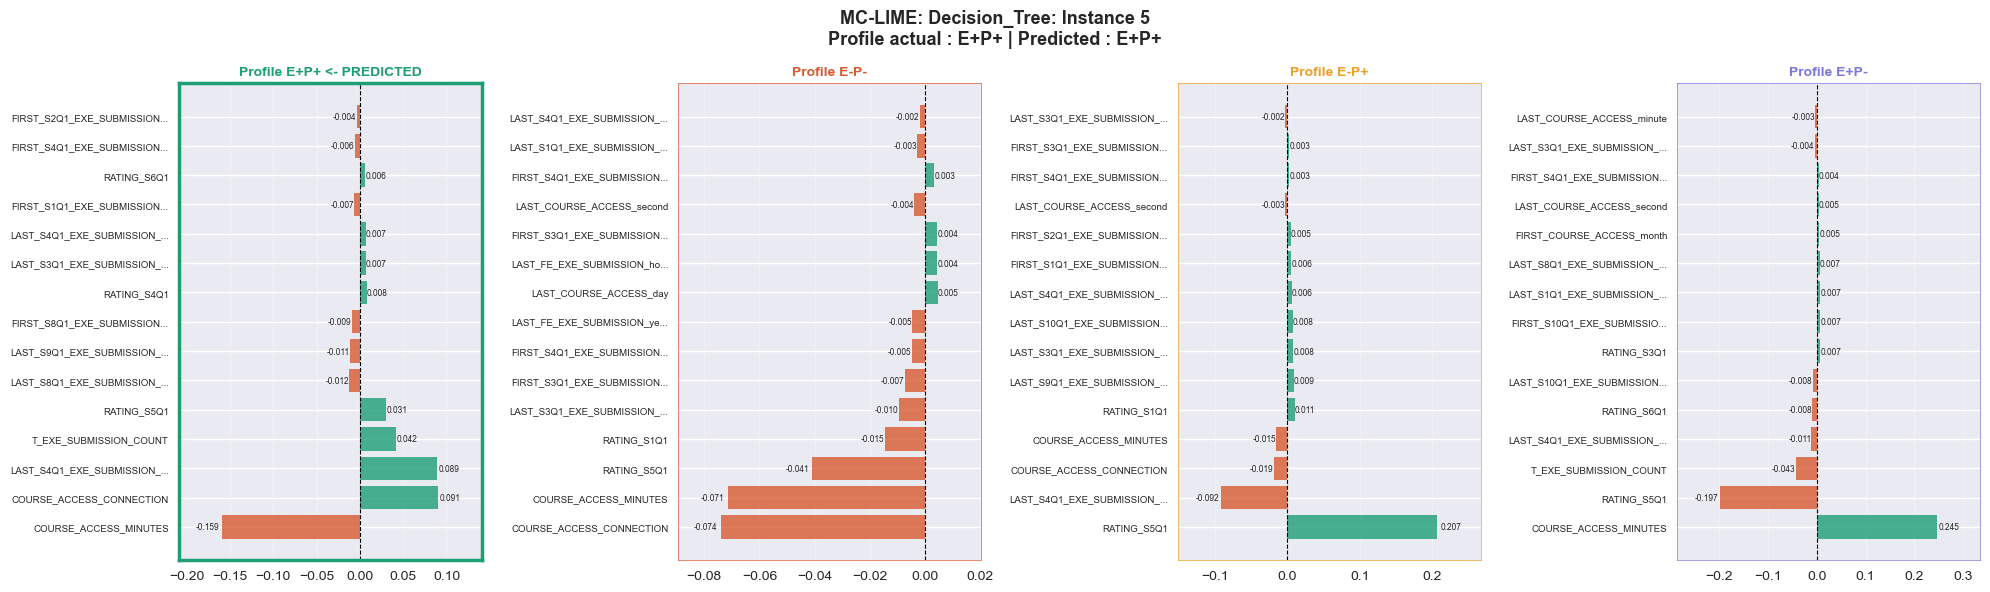

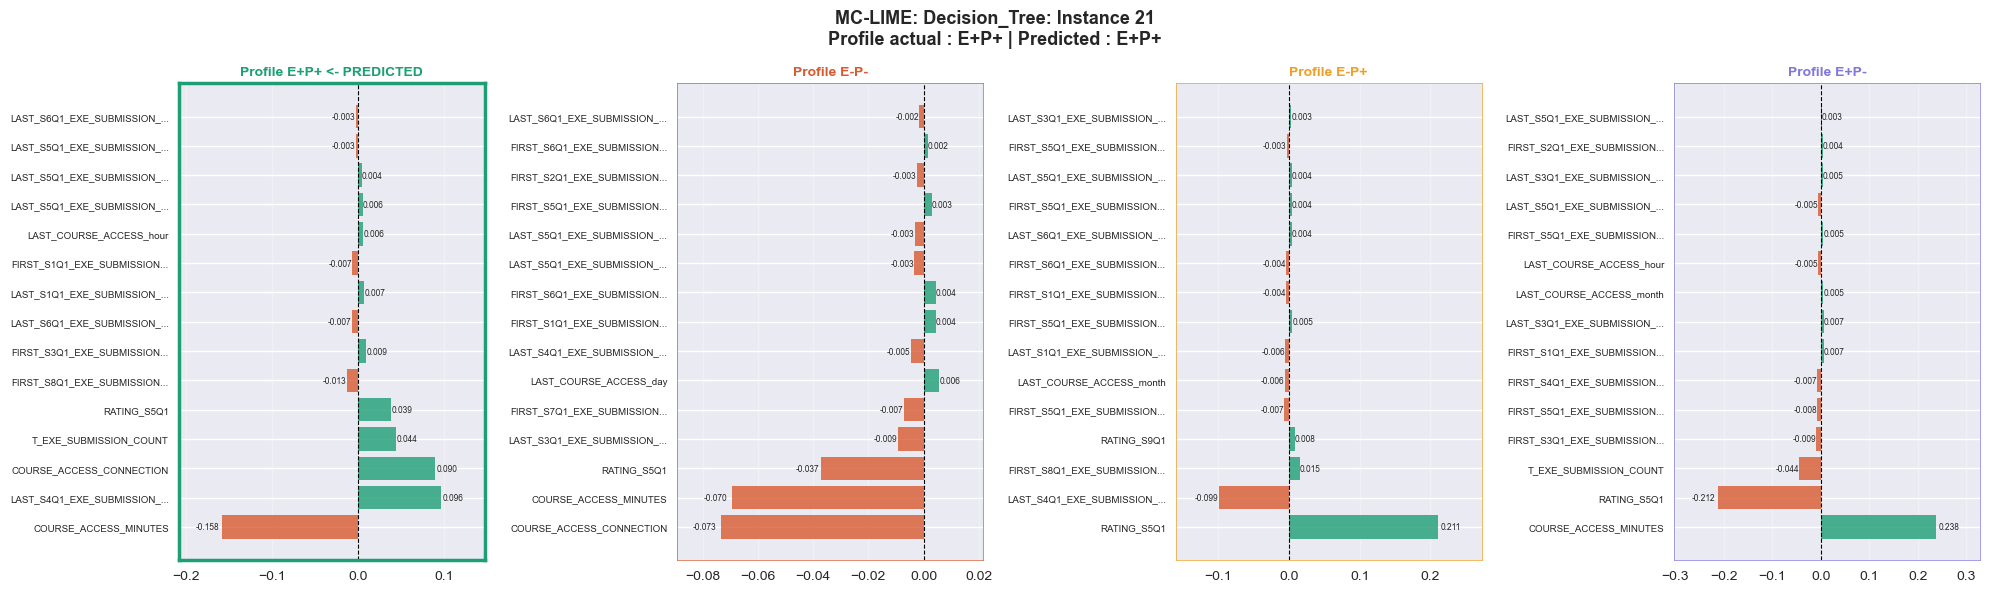

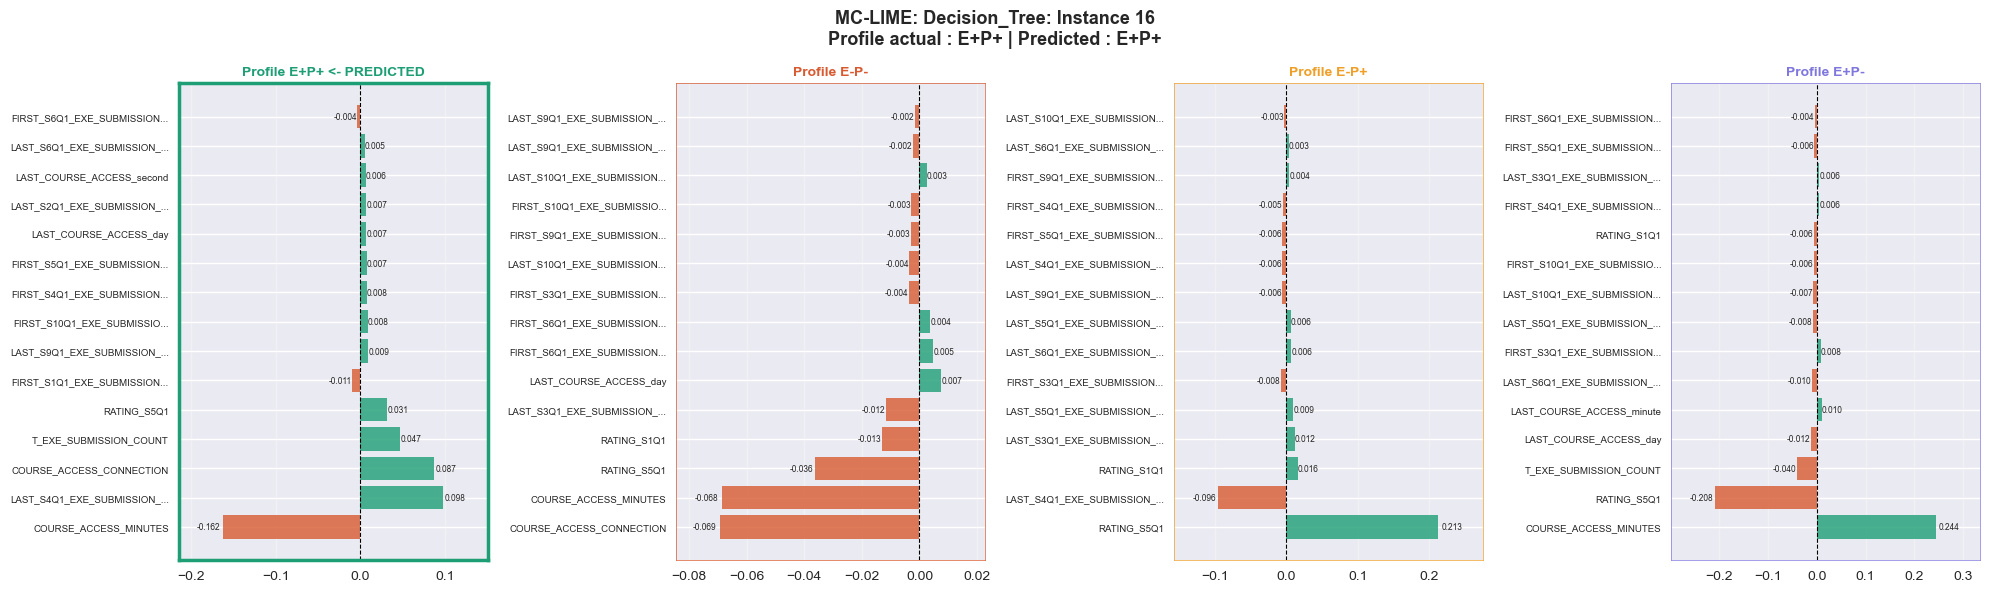

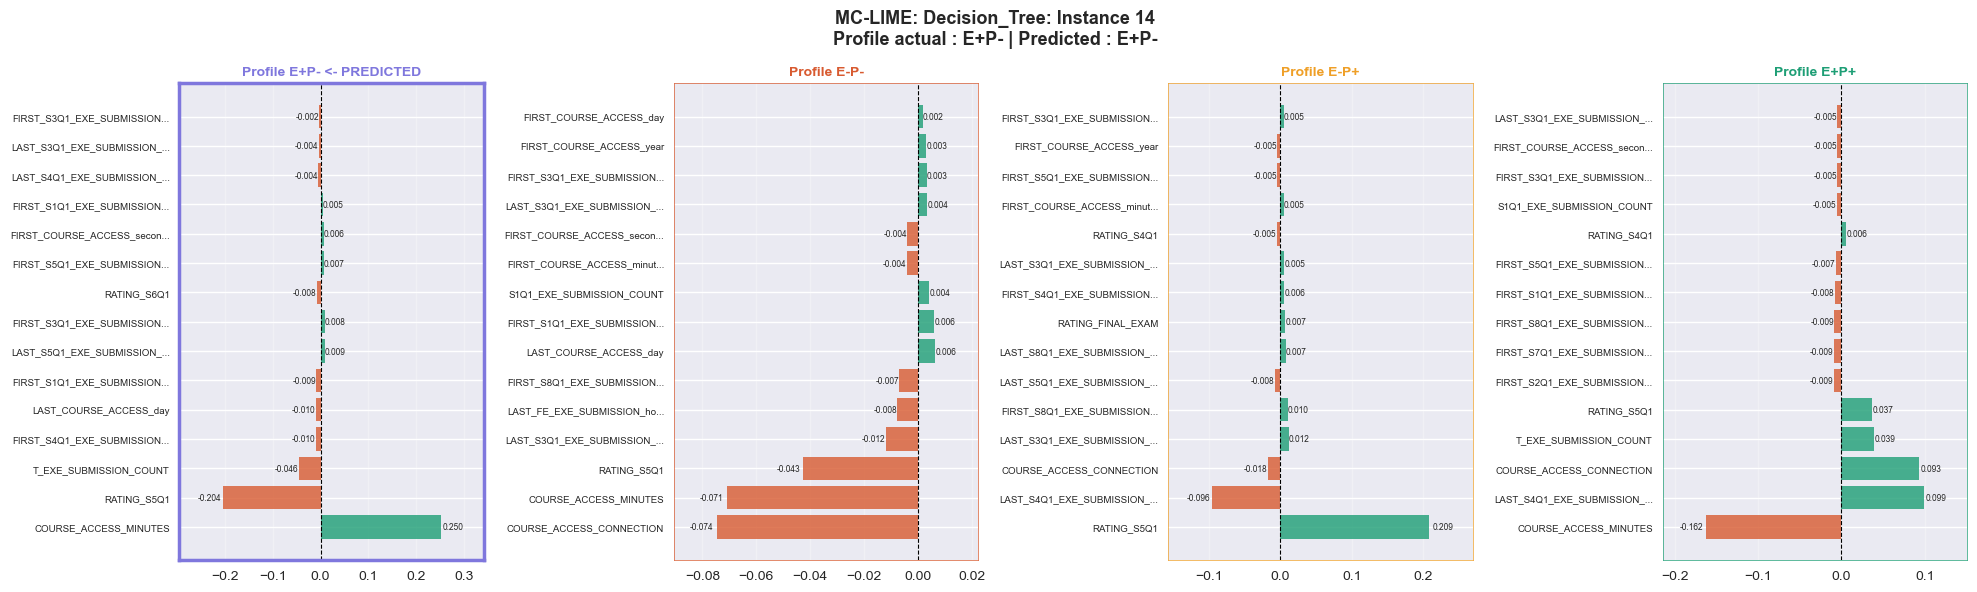

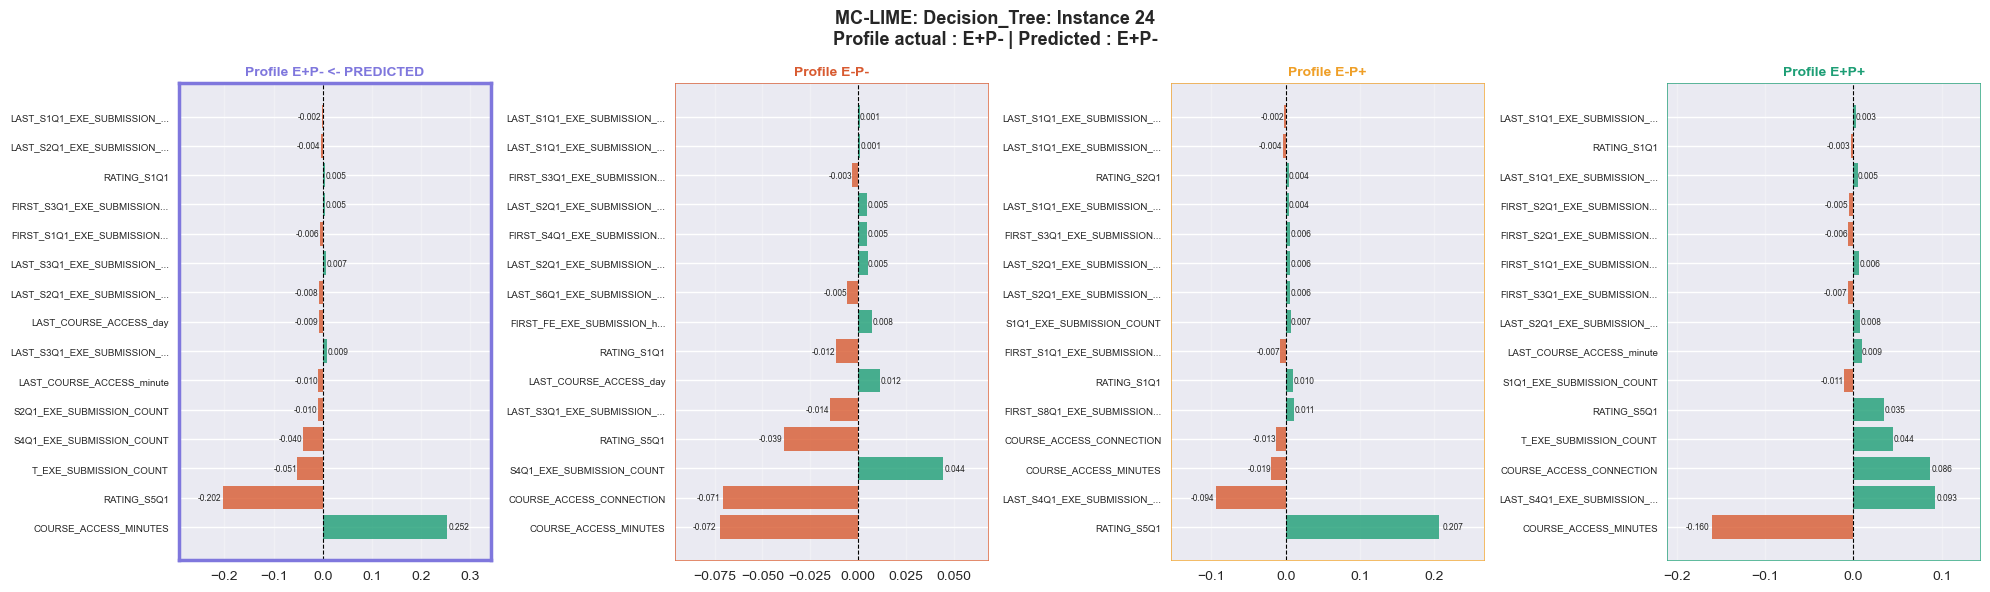

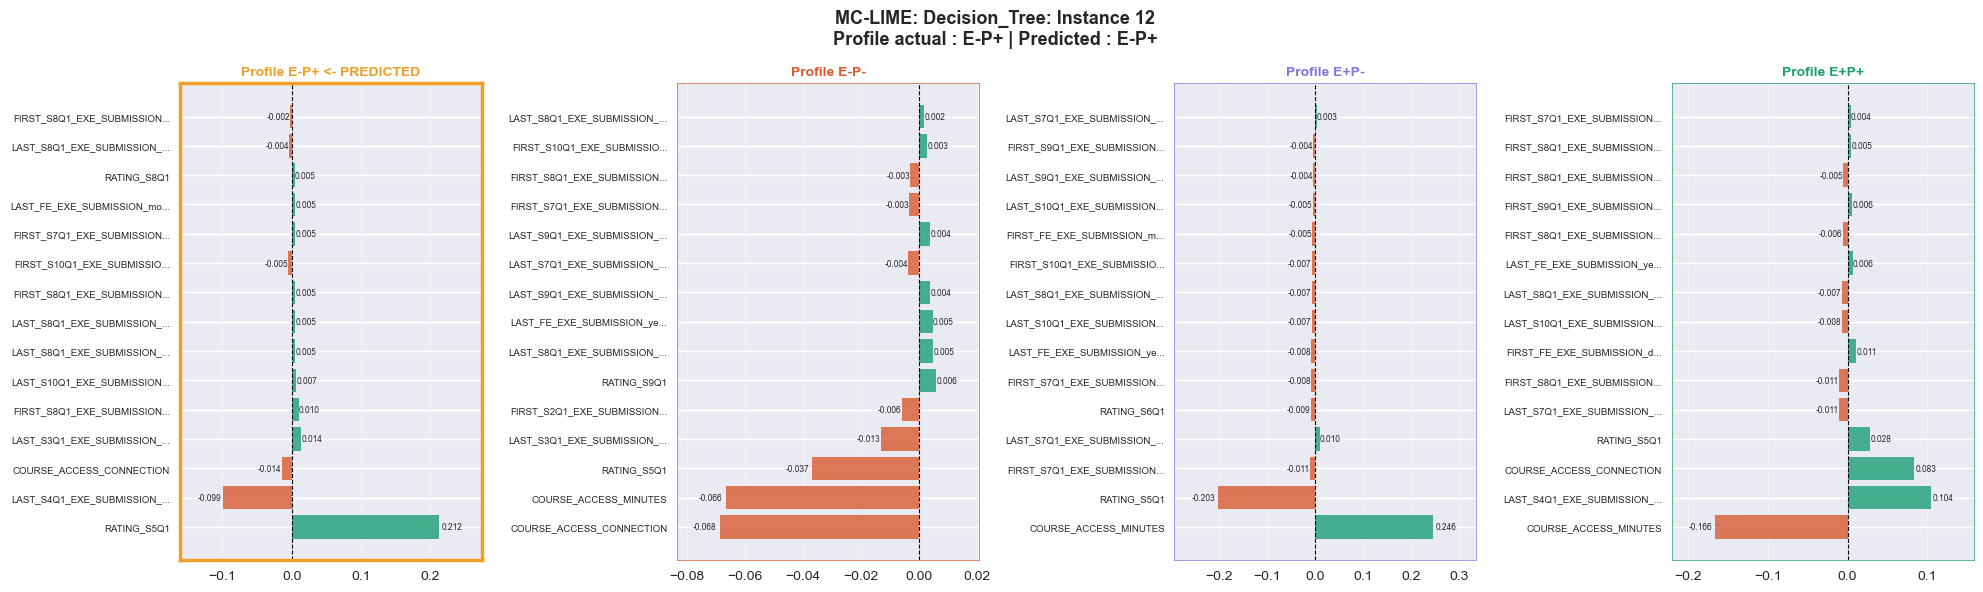

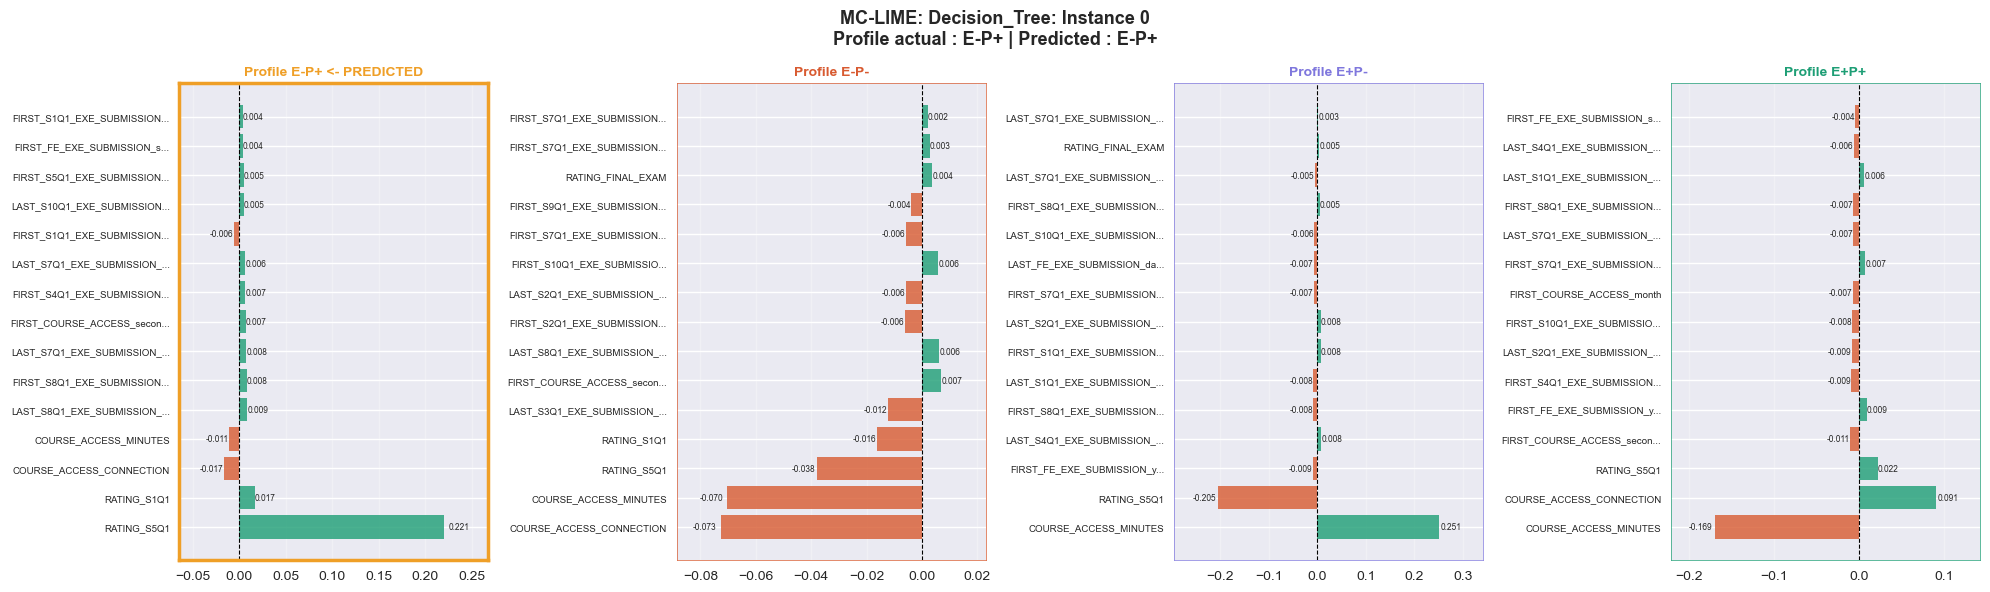

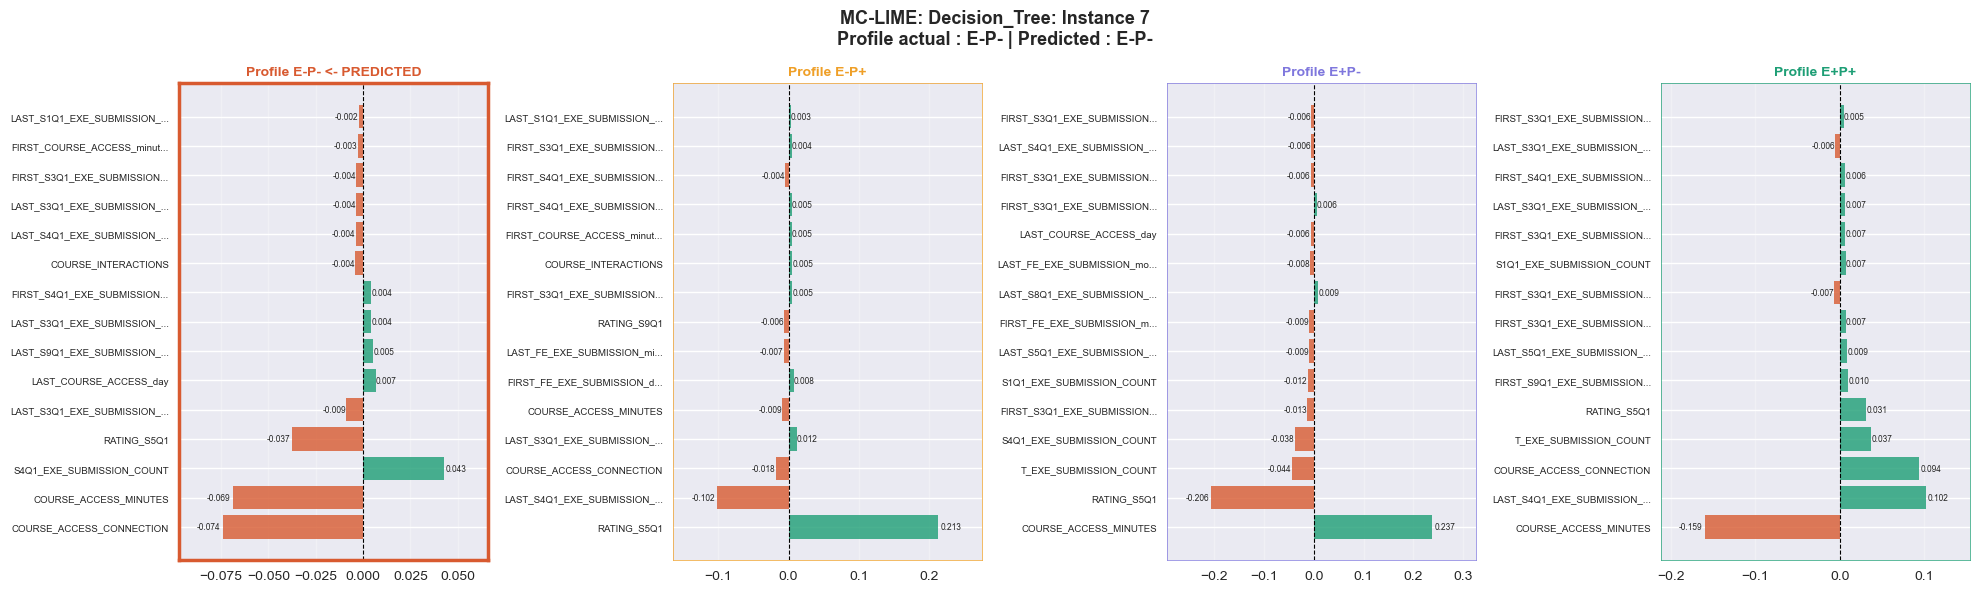

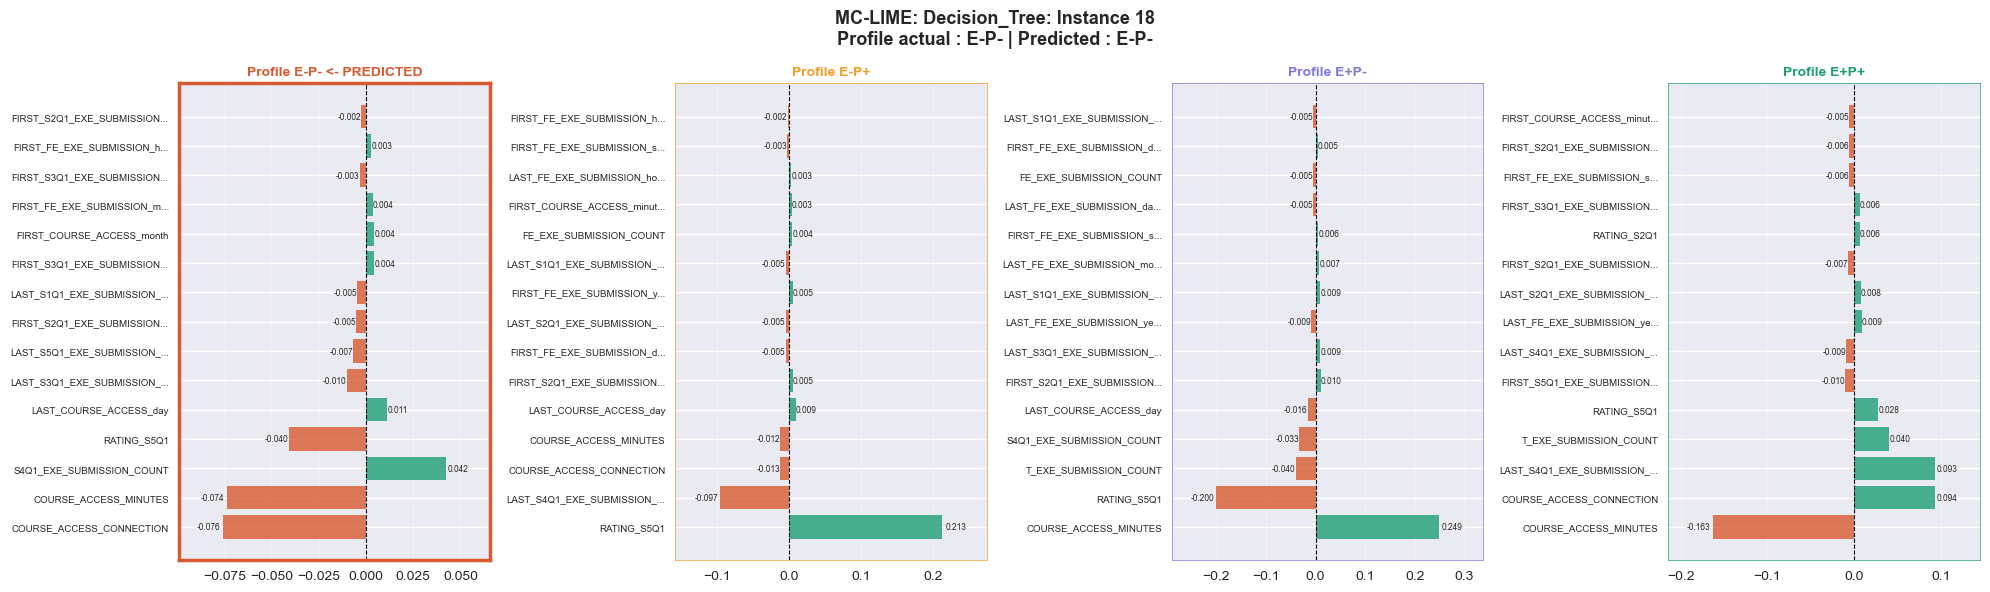

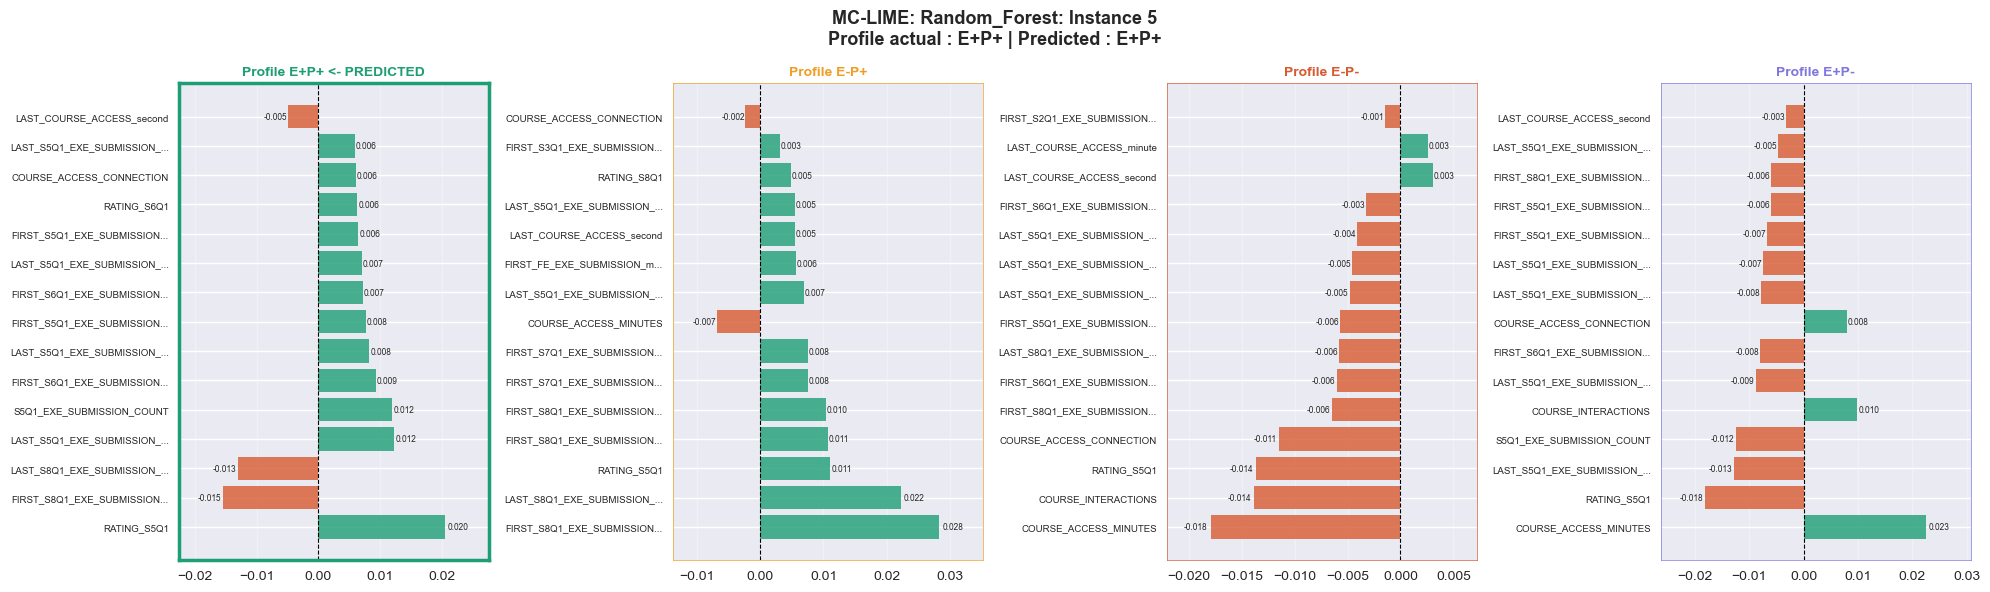

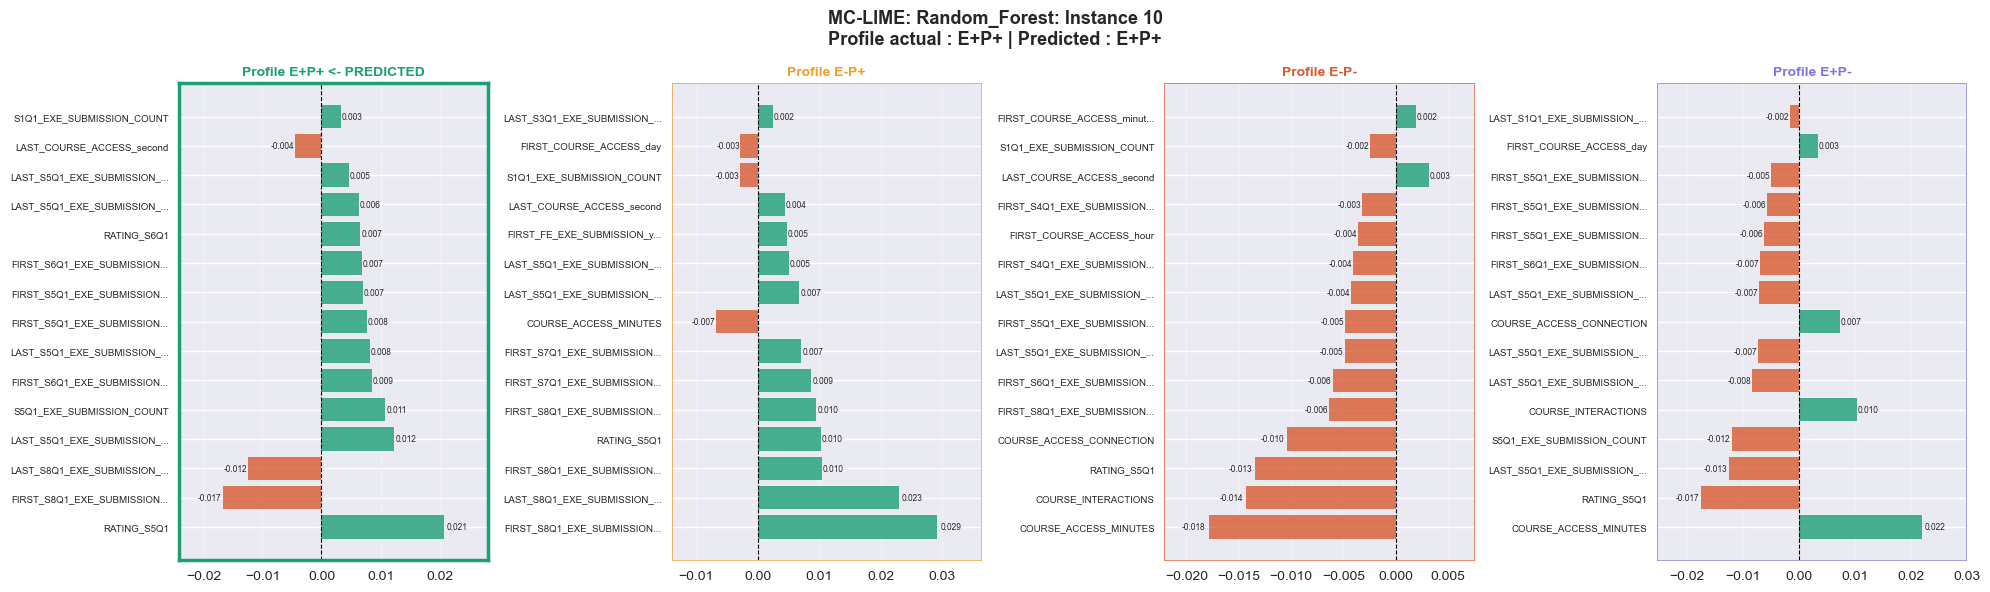

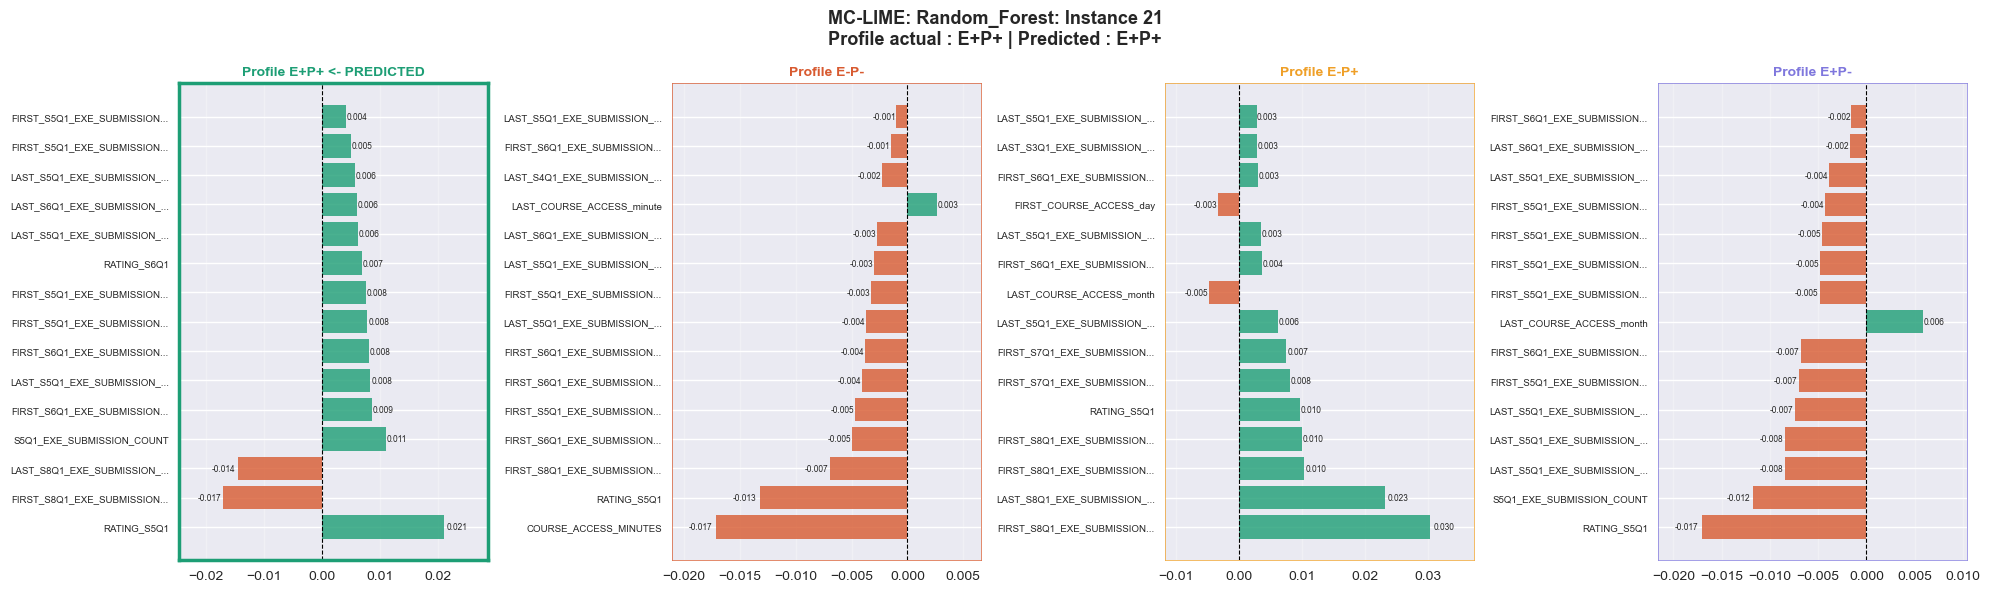

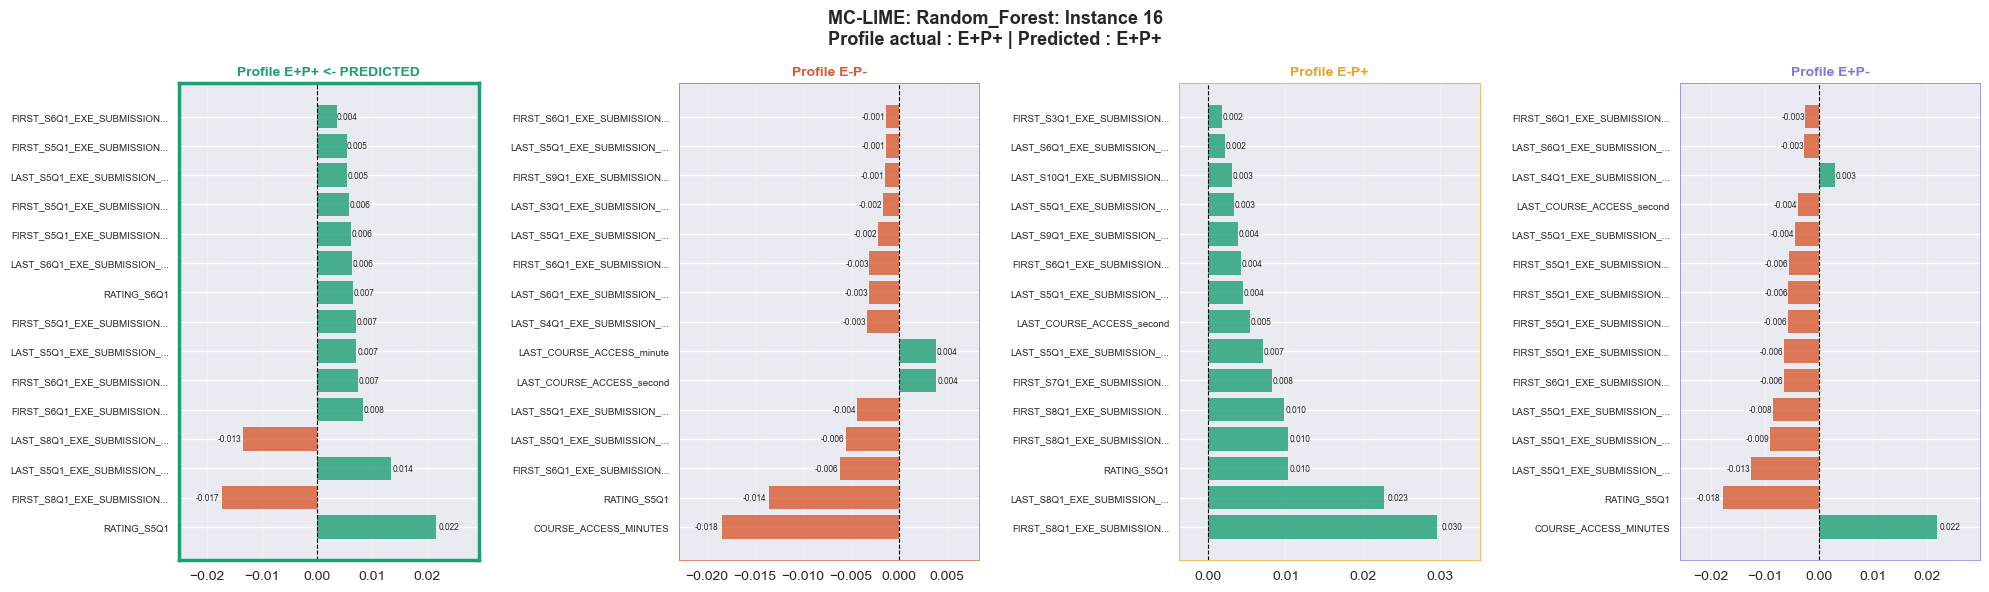

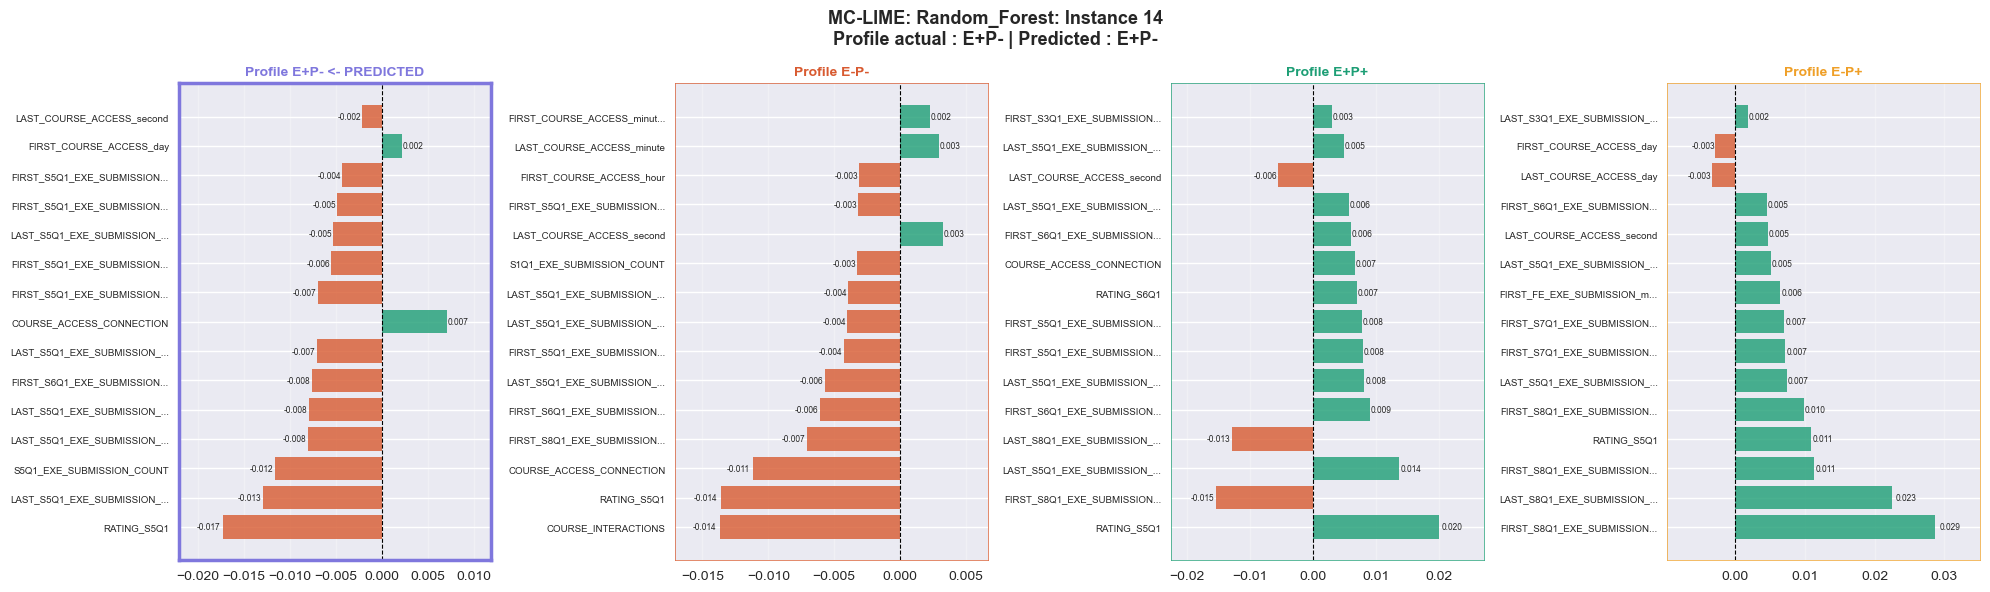

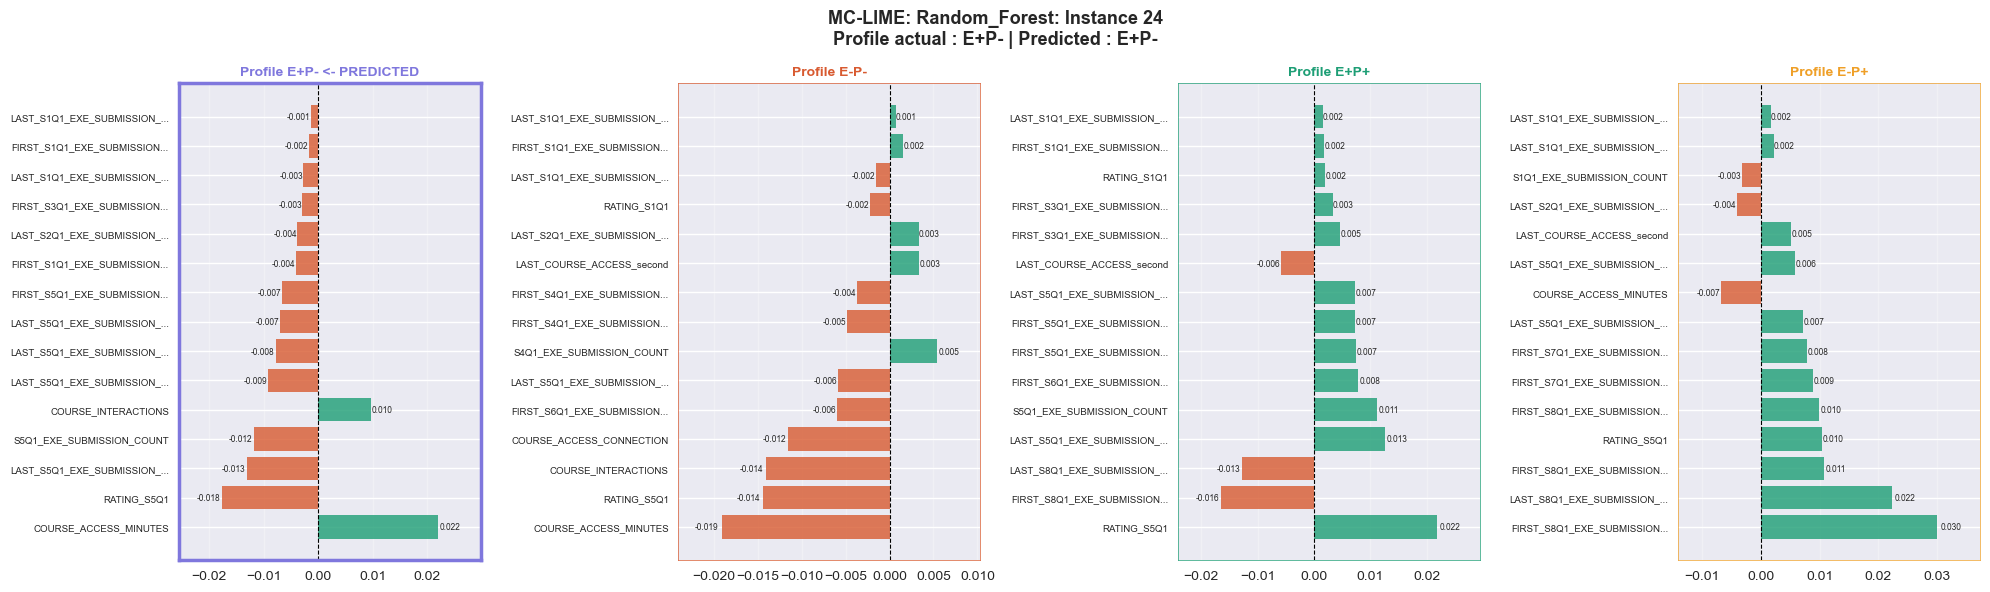

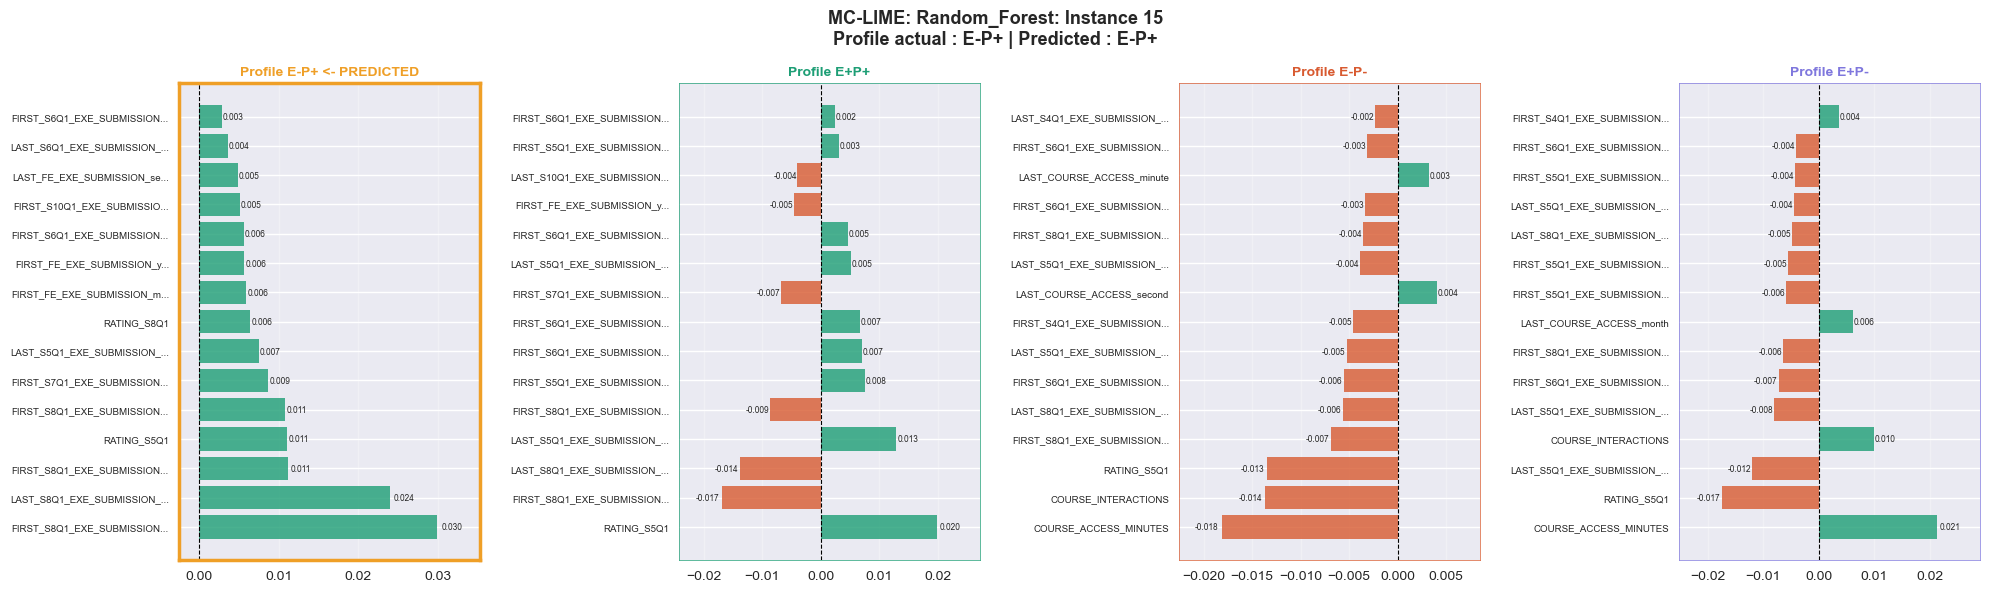

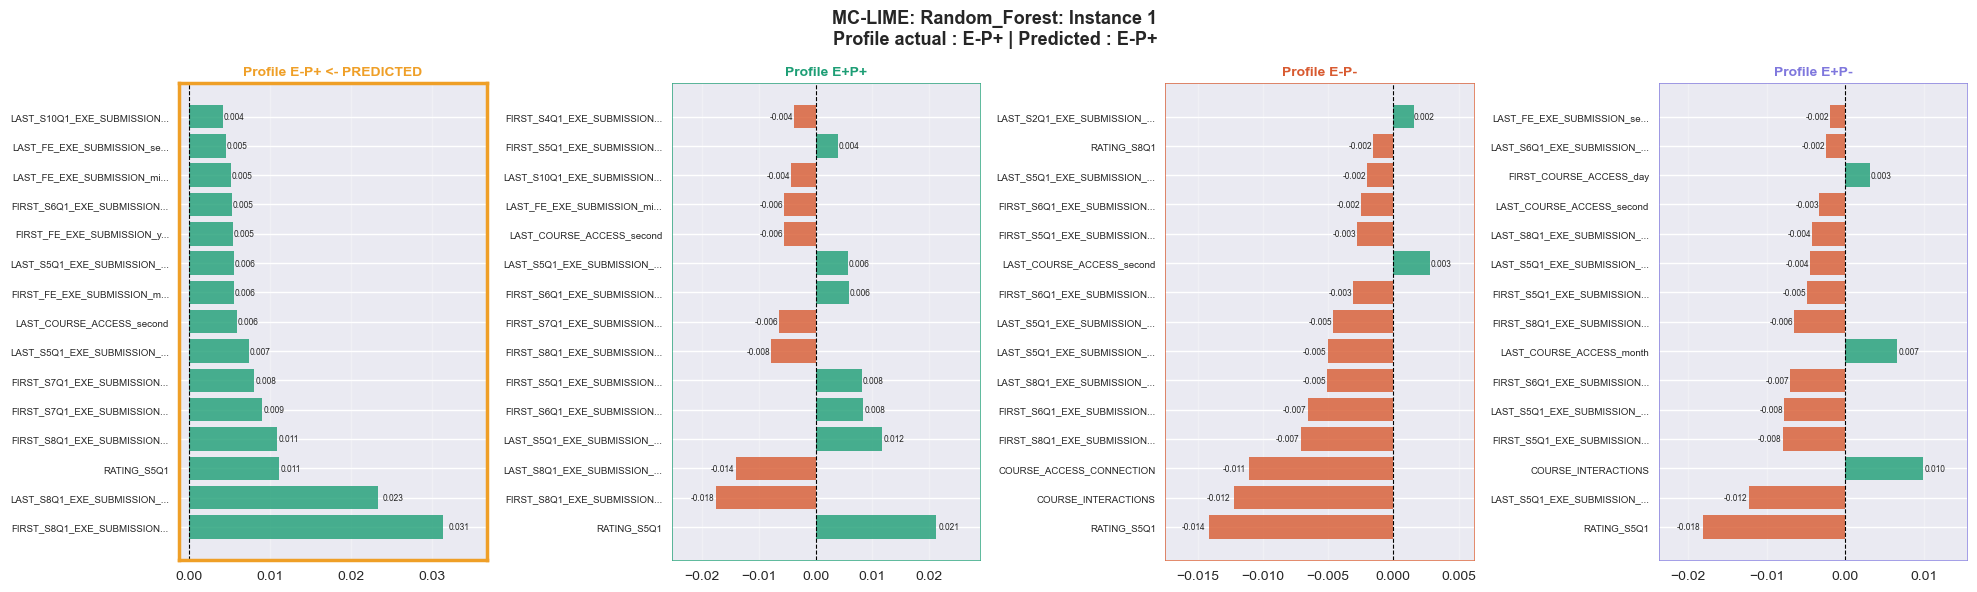

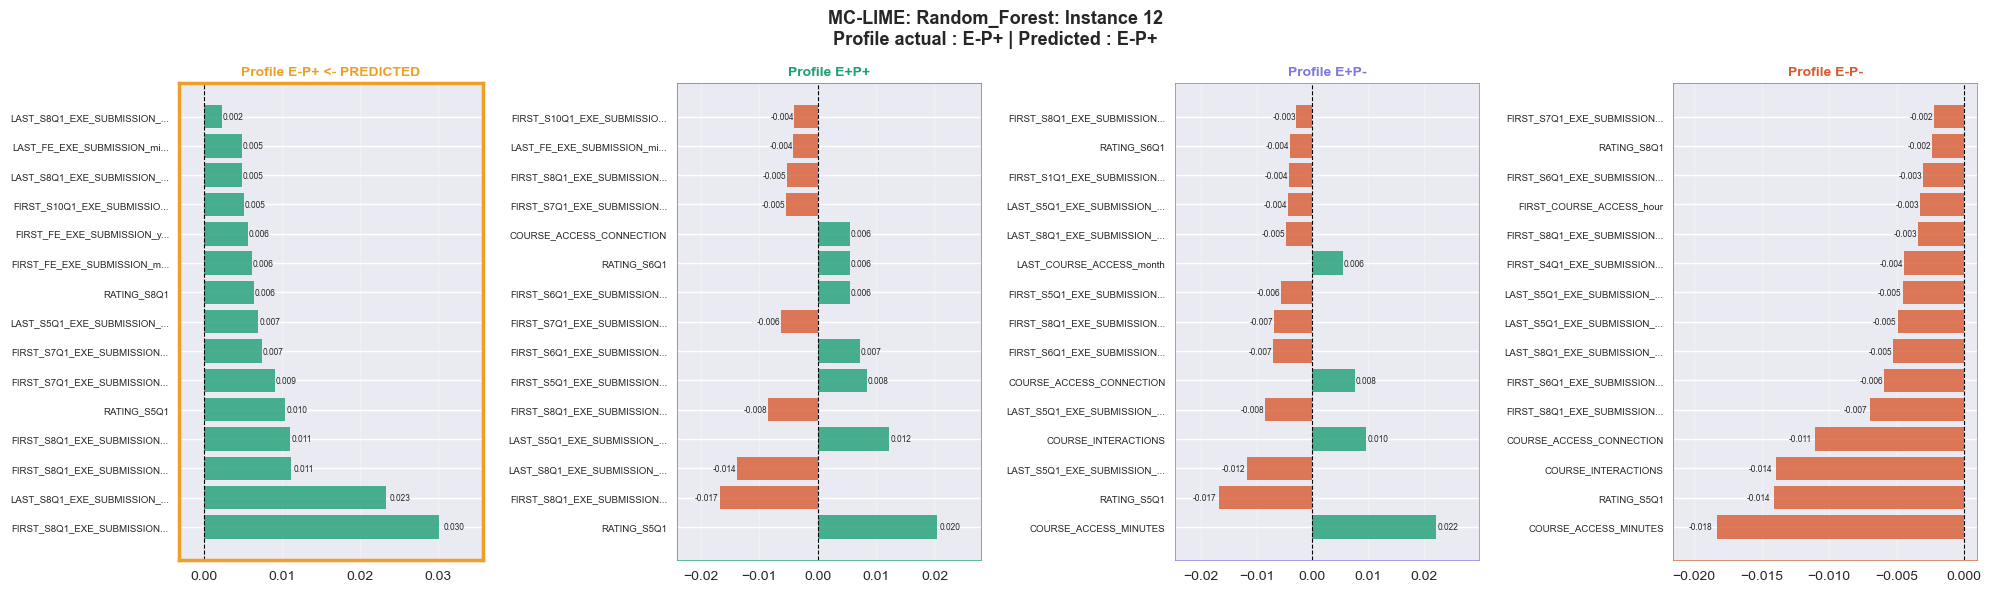

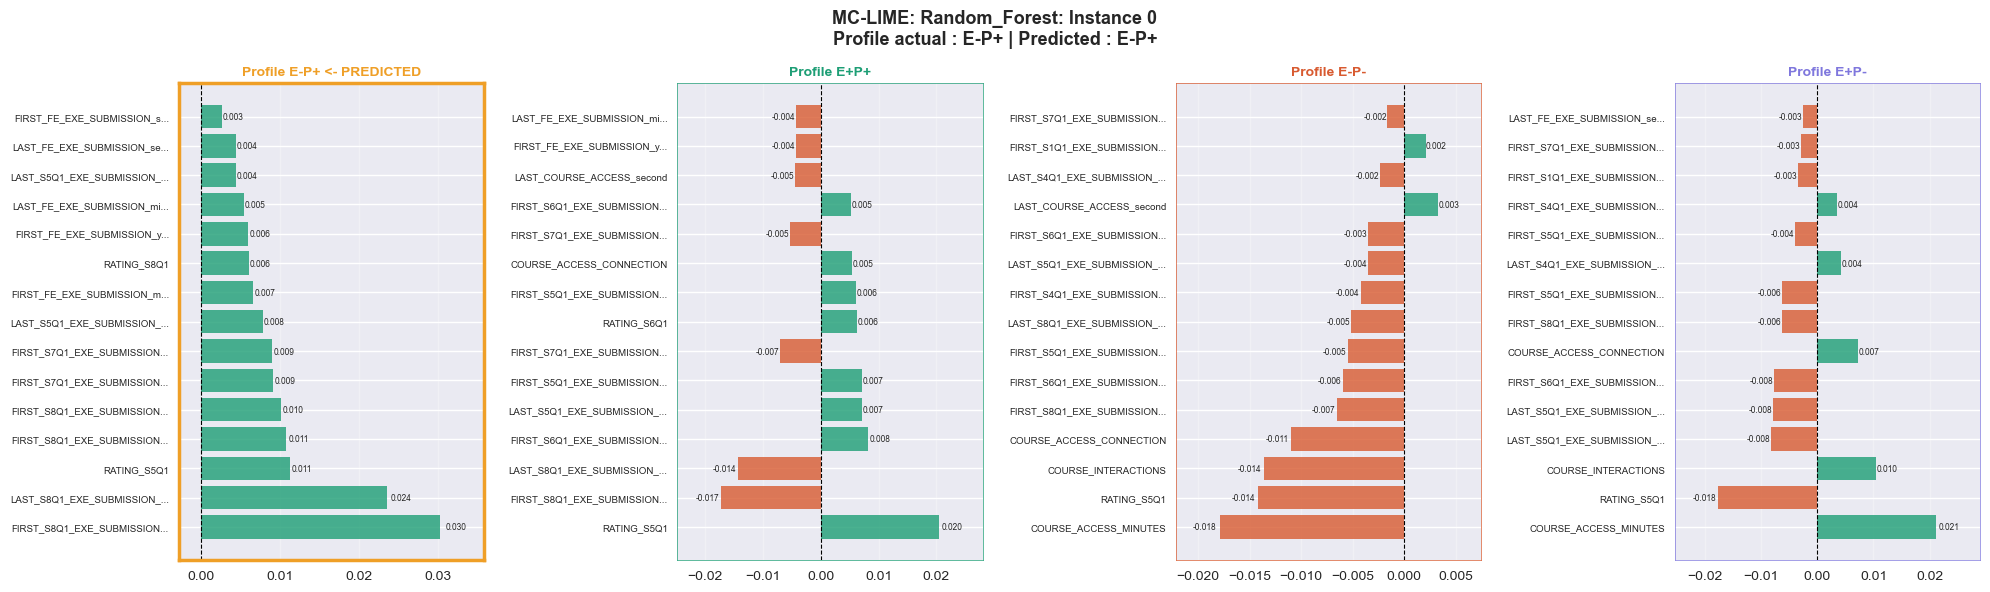

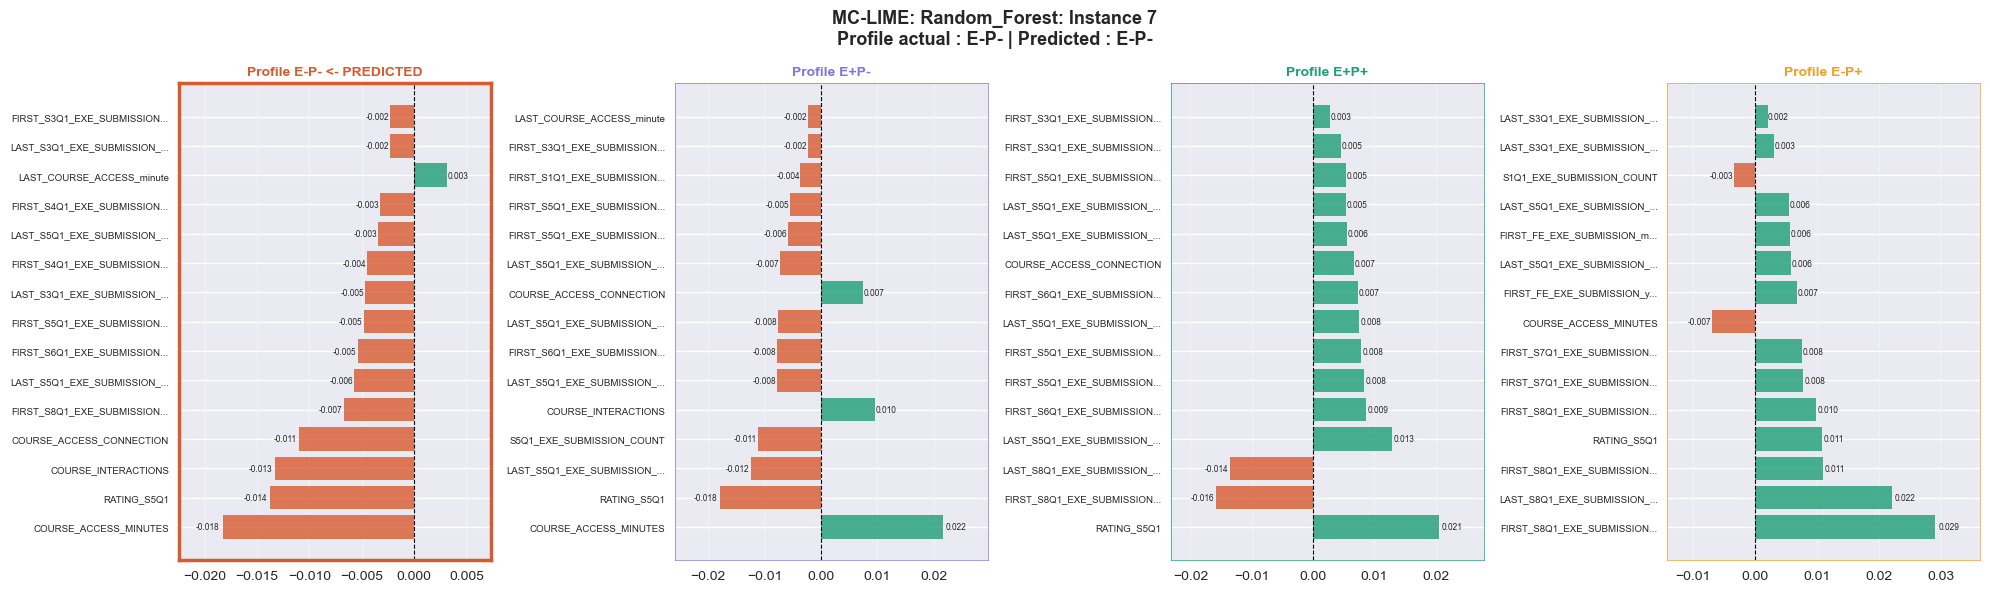

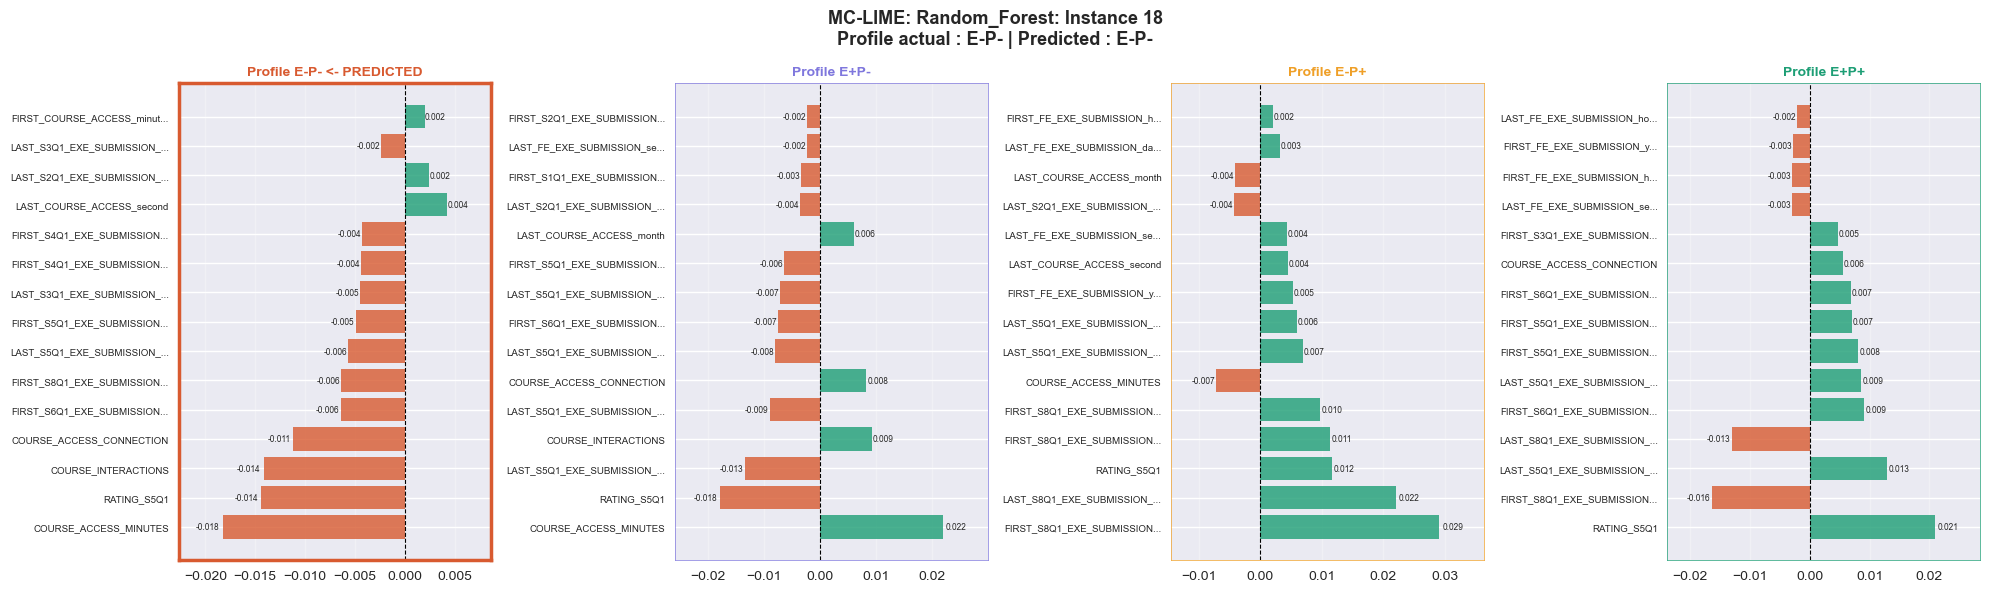

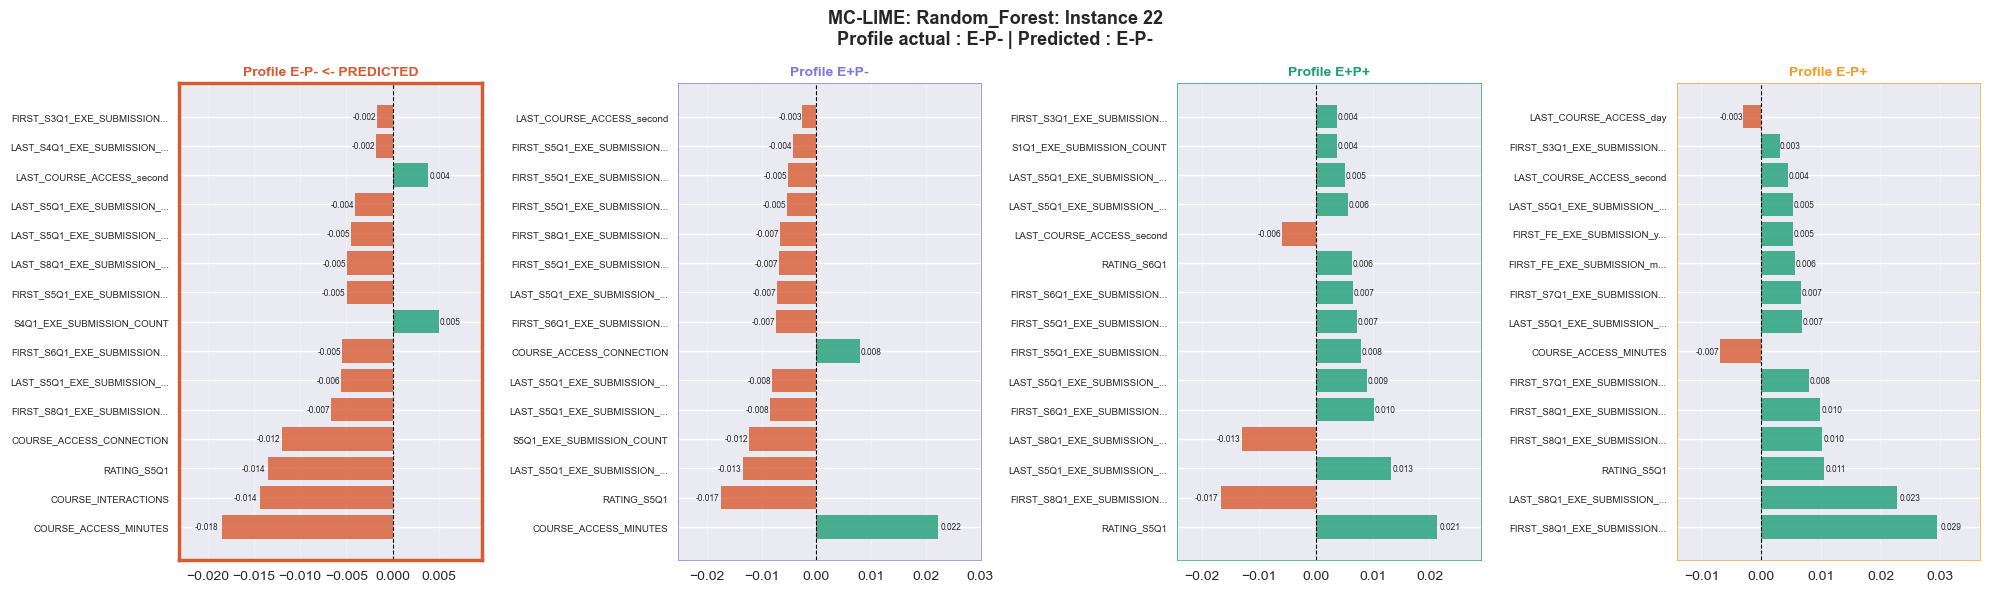


 HEATMAP: average contributions per profilee


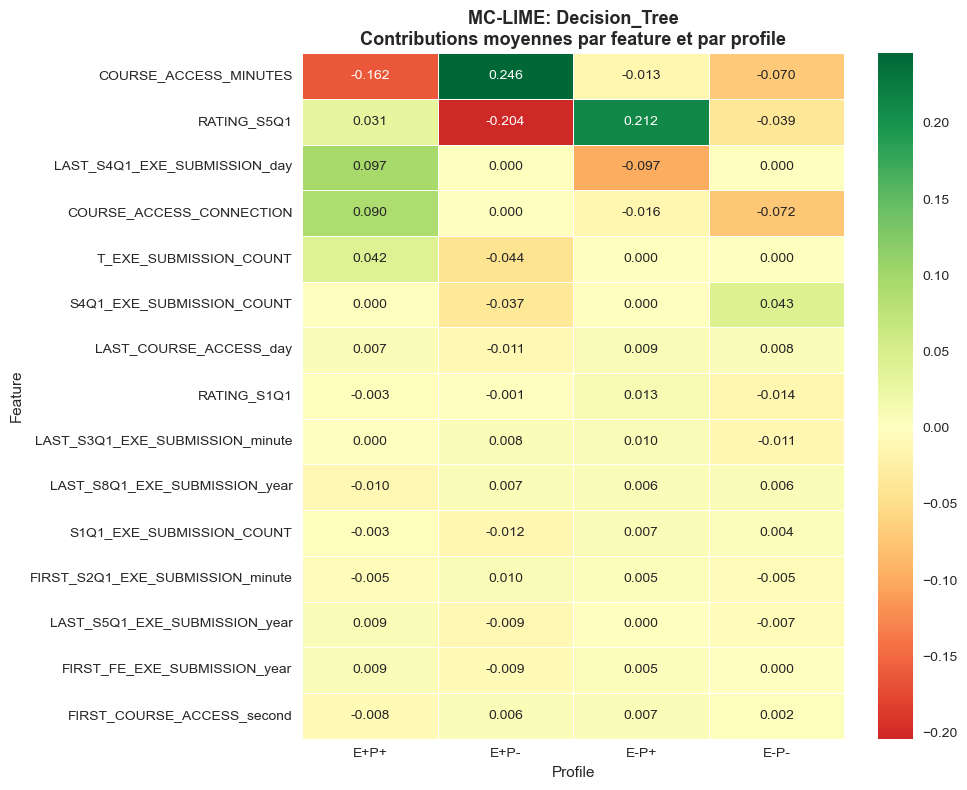

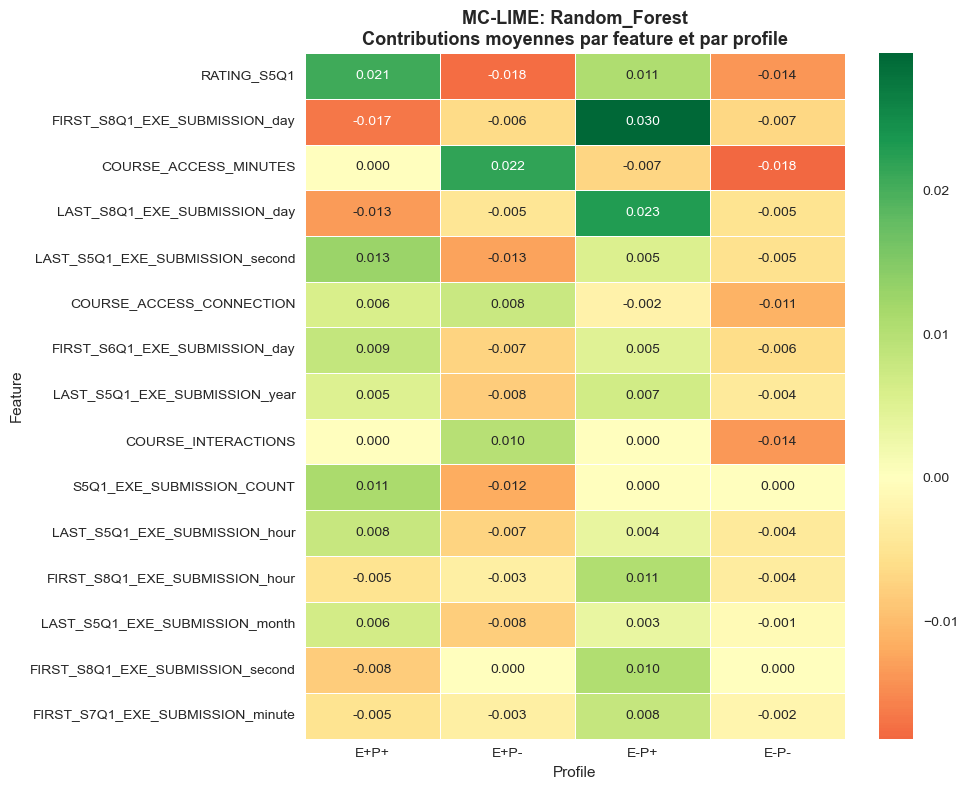

  WARNING Aucune donnée pour XGBoost: heatmap skipped
OK Export : outputs/mclime_explanations.csv
  1320 lignes | 13 instances | 2 models

 MC-LIME PIPELINE COMPLETE


In [9]:
mc_lime = MCLIMEEvaluator(evaluator)
mc_lime.run()